# Dit is een testbook

In [1]:
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


# 1. Introductie: Waarom goniometrie?

Waarom zou je je überhaupt bezighouden met iets als sinus en cosinus? Het klinkt als iets uit een stoffig wiskundeboek, maar de kans is groot dat je vandaag al tientallen keren in aanraking bent gekomen met goniometrie — zonder dat je het wist.

Denk eens aan een schommel op een speeltuin. Of aan het kloppende ritme van je hart. Misschien luister je nu naar muziek — ook dat is in essentie niets anders dan een opeenvolging van geluidsgolven. Golven, trillingen, herhalingen — ze zijn overal. En of je nu natuurkunde, economie, scheikunde of muziek studeert: periodieke bewegingen zijn fundamenteel.

In de natuurkunde beschrijven we een trillende veer of een slinger met een sinusfunctie. In de scheikunde zie je golven in reactiemechanismen of spectroscopie. In de economie verschijnen cycli in marktbewegingen — ook dat zijn patronen die je kunt benaderen met goniometrie. Zelfs in animatie en gaming worden rotaties van objecten wiskundig uitgedrukt met sinus en cosinus.

Maar waar komt dat allemaal vandaan? Hoe kan een ronddraaiend punt op een cirkel ineens de sleutel zijn tot het beschrijven van een golf? Dat is waar deze notebook over gaat. We beginnen met iets intuïtiefs: een veer met een blokje eraan. Daarmee bouwen we het begrip op van **harmonische beweging**, en zien we hoe de cirkelbeweging en de golfbeweging uiteindelijk **één en hetzelfde verhaal** vertellen — in de taal van de wiskunde: goniometrie.


## 2. Radialen vs. Graden

Een hoek kun je meten in **graden**, maar ook in **radialen**. Beide zijn maatvoeringen voor dezelfde eigenschap: de grootte van een hoek.  
Waarbij:

- ** $ 360° $ ** staat voor een volledige cirkel
- ** $ 2π $ radialen ** ook staat voor een volledige cirkel


### 2.1 Wat is een radiaal?

De **omtrek** van een cirkel is:

$$
C = 2\pi r
$$

Stel dat je maar een deel van een cirkel hebt — een "taartpunt". dan kun je de **booglengte** $ s $ berekenen met:

$$
s = \frac{\theta}{360^\circ} \cdot 2\pi r
$$

Hierin is:
- $ \theta $ : de hoek in graden
- $ r $ : de straal van de cirkel

---

#### Analogie: Pizza

Stel je voor: een pizza van 360°, netjes in 8 stukken gesneden, dus 45° per stuk. Als je 3 stukken eet, heb je $\frac{3 \cdot 45°}{360°} = \frac{3}{8} $ van de hele pizza.  
Zo werkt het ook met hoeken. Een hoek van 90° is $ \frac{1}{4} $ van een cirkel, dus:

$$
\theta = 90^\circ \Rightarrow s = \frac{1}{4} \cdot 2\pi r = \frac{\pi}{2} r
$$

---

Als de straal $ r = 1 $ is (de eenheidscirkel), dan wordt dit:

$$
s = \frac{\theta}{360^\circ} \cdot 2\pi
$$

$$
s = \frac{\pi}{180^\circ} \cdot \theta
$$

Deze booglengte $ s $  **is gelijk aan de hoek in radialen**, er onstaat dus een evenredigverband/ verhouding tussen graden en radialen:

$$
\theta_{\text{rad}} = \frac{\pi}{180^\circ} \cdot \theta_{\text{deg}} \cdot
$$

### 2.4 Visualisatie

Gebruik hieronder de interactieve eenheidscirkel om te zien hoe de **booglengte (in radialen)** overeenkomt met de **hoek (in graden)**.

- De blauwe straal geeft de hoek aan.
- De rode boog toont de bijbehorende radiaalwaarde.
- De radiaalwaarde verandert live mee met de schuifregelaar.


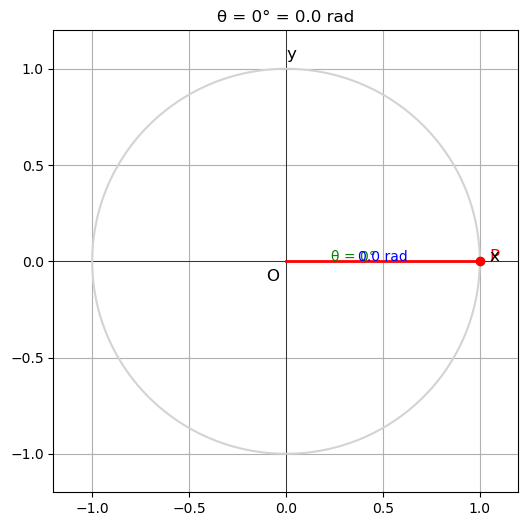

interactive(children=(IntSlider(value=0, description='Hoek θ (°)', max=360), Output()), _dom_classes=('widget-…

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import IntSlider, interact
from matplotlib.lines import Line2D




# Updatefunctie
def update(theta_deg):
    
    # Voorbereiding van figuur en plots
    plt.figure(figsize=(6, 6))
    plt.xlim(-1.2, 1.2)
    plt.ylim(-1.2, 1.2)
    plt.title("Eenheidscirkel met hoek θ")
    plt.grid(True)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)

    # Eenheidscirkel
    circle_theta = np.linspace(0, 2 * np.pi, 1000)
    circle_x = np.cos(circle_theta)
    circle_y = np.sin(circle_theta)
    plt.plot(circle_x, circle_y, 'lightgray')


    # Lijnen en objecten die we gaan updaten
    line_OP, = plt.plot([], [], 'r-', linewidth=2)
    arc_line, = plt.plot([], [], 'b--', linewidth=2)
    angle_arc, = plt.plot([], [], 'g-', linewidth=1.5)
    point_P, = plt.plot([], [], 'ro')

    # Teksten die we updaten
    text_P = plt.text(0, 0, '', fontsize=12, color='red')
    text_deg = plt.text(0, 0, '', fontsize=10, color='green', ha='center')
    text_rad = plt.text(0, 0, '', fontsize=10, color='blue', ha='center')

    # Extra vaste labels
    plt.text(1.05, 0, 'x', fontsize=12)
    plt.text(0, 1.05, 'y', fontsize=12)
    plt.text(-0.1, -0.1, 'O', fontsize=12)


    theta_rad = np.radians(theta_deg)
    x = np.cos(theta_rad)
    y = np.sin(theta_rad)

    # Update lijn OP
    line_OP.set_data([0, x], [0, y])

    # Update boog
    arc_theta = np.linspace(0, theta_rad, 300)
    arc_line.set_data(np.cos(arc_theta), np.sin(arc_theta))

    # Hoekboogje
    angle_arc_theta = np.linspace(0, theta_rad, 100)
    angle_arc_r = 0.3
    angle_arc.set_data(angle_arc_r * np.cos(angle_arc_theta),
                       angle_arc_r * np.sin(angle_arc_theta))

    # Punt P
    point_P.set_data([x], [y])
    text_P.set_position((x + 0.05 * np.sign(x), y + 0.05 * np.sign(y)))
    text_P.set_text("P")

    # Hoeklabels
    text_deg.set_position((0.35 * np.cos(theta_rad / 2), 0.35 * np.sin(theta_rad / 2)))
    text_deg.set_text(f"θ = {theta_deg}°")

    text_rad.set_position((0.5 * np.cos(theta_rad / 2), 0.5 * np.sin(theta_rad / 2)))
    text_rad.set_text(f"{round(theta_rad, 2)} rad")

    # Titel
    plt.title(f"θ = {theta_deg}° = {round(theta_rad, 2)} rad")

 

# Interactieve slider
interact(update, theta_deg=IntSlider(min=0, max=360, step=1, value=0, description="Hoek θ (°)"));

#### Tabel: graden vs. radialen

De meest voorkomende hoeken zijn in de onsterstaande tabel weergeven.

| Hoek in graden (°)  | Hoek in radialen (rad) |
|---------------------|------------------------|
| 0°                  | 0                      |
| 30°                 | $ \frac{1}{6} \pi $    |
| 45°                 | $ \frac{1}{4} \pi $    |
| 60°                 | $ \frac{1}{3} \pi $    |
| 90°                 | $ \frac{1}{2} \pi $    |
| 180°                | $ \pi $                |
| 270°                | $ \frac{3}{2} \pi $    |
| 360°                | $ 2\pi $               |

---


### 2.2 Omrekenen tussen graden en radialen

#### Rekenen met een verhoudingsfactor

We kunnen de relatie tussen graden en radialen als een **formule** opschrijven:

- Van graden naar radialen:

$$
\theta_{\text{rad}} = \theta_{\text{deg}} \cdot \frac{\pi}{180^\circ}
$$

- Van radialen naar graden:

$$
\theta_{\text{deg}} = \theta_{\text{rad}} \cdot \frac{180^\circ}{\pi}
$$

 
Zo kunnen we bijvoorbeeld berekenen dat: 1 radiaal ≈ 57,3°

---

#### Rekenen met een verhoudingstabel

Je kunt ook gebruik maken van een kruistabel:

|                        | Hele cirkel $ C $ | Deel van de cirkel $ s $ |
|------------------------|-------------------|--------------------------|
| Graden                 | 360°              | 90°                      |
| Radialen               | $ 2\pi $          | ?                        |

Kruisproduct:

$$
360^\circ \cdot \theta = 2\pi \cdot 90^\circ \Rightarrow \theta = \frac{2\pi \cdot 90^\circ}{360^\circ}= \frac{\pi}{2}
$$


## 3. De eenheidscirkel en goniometrische functies


De **eenheidscirkel** is een cirkel met straal $r = 1$ en het middelpunt in de oorsprong $(0,0)$.  
Voor elke hoek $\theta$ kun je een punt $P(x, y)$ op de cirkel aangeven. Dat punt ligt op de rand van de cirkel, op een afstand van 1 vanaf het middelpunt.  

We zijn geïnteresseerd in de vraag:  
> "Hoe hangen de coördinaten $x$ en $y$ van het punt $P$ samen met de hoek $\theta$?"

---

### 3.1 Van een hoek naar coördinaten

Teken een straal van het middelpunt $(0,0)$ naar het punt $P(x,y)$ op de cirkel. Dit vormt een rechthoekige driehoek als je een lijn tekent van $P$ loodrecht naar de $x$-as.  

We kunnen deze driehoek analyseren met behulp van goniometrische verhoudingen:

- **Sinus (SOS):**
  $$
  \sin(\theta) = \frac{\text{overstaande}}{\text{schuine zijde}} = \frac{y}{1} \Rightarrow y = \sin(\theta)
  $$

- **Cosinus (CAS):**
  $$
  \cos(\theta) = \frac{\text{aanliggende}}{\text{schuine zijde}} = \frac{x}{1} \Rightarrow x = \cos(\theta)
  $$

- **Tangens (TOA):**
  $$
  \tan(\theta) = \frac{y}{x}
  $$

Dus het punt $P$ op de eenheidscirkel kan worden uitgedrukt als:

$$
P(x, y) = (\cos(\theta), \sin(\theta))
$$

---

#### Visualisatie

In de grafiek hieronder zie je de eenheidscirkel.  
Met de schuifregelaar kun je de hoek $\theta$ aanpassen. Het bijbehorende punt $P$ verschuift over de cirkel, en je ziet hoe de x- en y-waarden veranderen.

- De **rode lijn** volgt de $x$-waarde: $\cos(\theta)$  
- De **blauwe lijn** volgt de $y$-waarde: $\sin(\theta)$

---


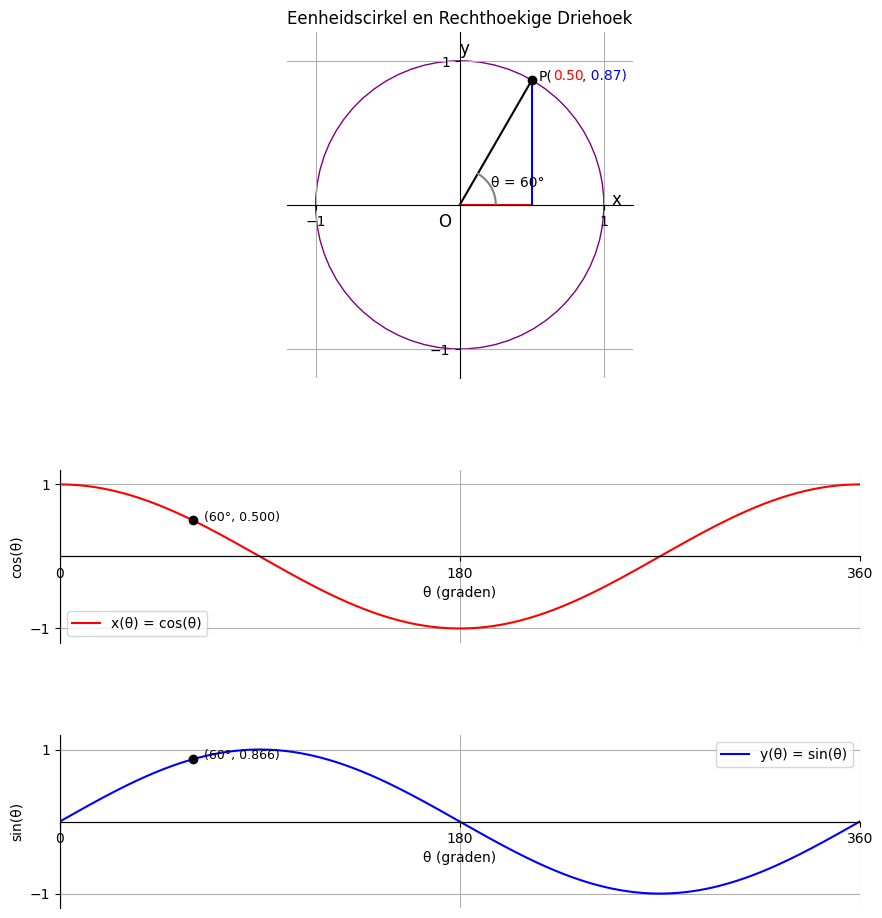

interactive(children=(IntSlider(value=60, description='θ (graden)', max=360), Output()), _dom_classes=('widget…

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import IntSlider, interact
import matplotlib.gridspec as gridspec

def plot_figure(theta):
    # Zet figuur opnieuw op bij elke update
    fig = plt.figure(figsize=(10, 12))
    gs = gridspec.GridSpec(3, 1, height_ratios=[2, 1, 1])
    ax_circle = plt.subplot(gs[0])
    ax_cos = plt.subplot(gs[1])
    ax_sin = plt.subplot(gs[2])
    plt.subplots_adjust(left=0.1, bottom=0.15, hspace=0.4)

    # Eenheidscirkel
    circle = plt.Circle((0, 0), 1, color='purple', fill=False)
    ax_circle.add_artist(circle)
    ax_circle.set_xlim(-1.2, 1.2)
    ax_circle.set_ylim(-1.2, 1.2)
    ax_circle.set_aspect('equal')
    ax_circle.grid(True)
    ax_circle.set_title("Eenheidscirkel en Rechthoekige Driehoek")

    # Assen door oorsprong
    ax_circle.spines['left'].set_position('zero')
    ax_circle.spines['bottom'].set_position('zero')
    ax_circle.spines['right'].set_color('none')
    ax_circle.spines['top'].set_color('none')
    ax_circle.xaxis.set_ticks([-1, 1])
    ax_circle.yaxis.set_ticks([-1, 1])
    ax_circle.text(1.05, 0, 'x', fontsize=12)
    ax_circle.text(0, 1.05, 'y', fontsize=12)
    ax_circle.text(-0.15, -0.15, 'O', fontsize=12)

    # Hoek en coördinaten
    theta_rad = np.deg2rad(theta)
    x = np.cos(theta_rad)
    y = np.sin(theta_rad)

    # Rechthoekige driehoek
    ax_circle.plot([0, x], [0, y], color='black')  # Hypotenusa
    ax_circle.plot([0, x], [0, 0], color='red')     # x-component
    ax_circle.plot([x, x], [0, y], color='blue')    # y-component
    ax_circle.plot(x, y, 'ko')                      # Punt P
    ax_circle.text(x + 0.05, y, f'P(', fontsize=10)
    ax_circle.text(x + 0.15, y, f'{x:.2f}', fontsize=10, color='red')
    ax_circle.text(x + 0.35, y, f', {y:.2f})', fontsize=10, color='blue')

    # Hoekboog
    arc_radius = 0.25
    arc_angle = np.linspace(0, theta_rad, 100)
    arc_x = arc_radius * np.cos(arc_angle)
    arc_y = arc_radius * np.sin(arc_angle)
    ax_circle.plot(arc_x, arc_y, 'gray')
    ax_circle.text(
        arc_radius * np.cos(theta_rad / 2),
        arc_radius * np.sin(theta_rad / 2),
        f'θ = {int(theta)}°',
        fontsize=10
    )

    # Cos/Sin-grafieken
    theta_deg = np.linspace(0, 360, 1000)
    theta_rad_all = np.deg2rad(theta_deg)
    cos_vals = np.cos(theta_rad_all)
    sin_vals = np.sin(theta_rad_all)

    ax_cos.plot(theta_deg, cos_vals, label='x(θ) = cos(θ)', color='red')
    ax_cos.plot(theta, np.cos(theta_rad), 'ko')
    ax_cos.text(theta + 5, np.cos(theta_rad), f'({int(theta)}°, {np.cos(theta_rad):.3f})', fontsize=9)

    ax_sin.plot(theta_deg, sin_vals, label='y(θ) = sin(θ)', color='blue')
    ax_sin.plot(theta, np.sin(theta_rad), 'ko')
    ax_sin.text(theta + 5, np.sin(theta_rad), f'({int(theta)}°, {np.sin(theta_rad):.3f})', fontsize=9)

    for ax, ylabel in zip([ax_cos, ax_sin], ['cos(θ)', 'sin(θ)']):
        ax.set_xlim(0, 360)
        ax.set_ylim(-1.2, 1.2)
        ax.grid(True)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_ylabel(ylabel)
        ax.set_xlabel('θ (graden)')
        ax.spines['left'].set_position('zero')
        ax.spines['bottom'].set_position('zero')
        ax.spines['right'].set_color('none')
        ax.spines['top'].set_color('none')
        ax.set_xticks([0, 180, 360])
        ax.set_yticks([-1, 1])
        ax.legend()

    plt.show()

# Interactieve slider
interact(plot_figure, theta=IntSlider(min=0, max=360, step=1, value=60, description='θ (graden)'));

### 3.2 Samenhang van eenheidscirkel en sinusgolf

Wanneer we een volledige omwenteling maken (van $0^\circ$ tot $360^\circ$), verandert het teken van $\sin(\theta)$ en $\cos(\theta)$ afhankelijk van het **kwadrant** waarin punt $P$ ligt:

| Kwadrant       | $\theta$-bereik         | Teken van $\cos(\theta)$ | Teken van $\sin(\theta)$ | Coördinaat $P(x, y)$ |
|----------------|--------------------------|---------------------------|---------------------------|----------------------|
| 1e kwadrant    | $0^\circ$ – $90^\circ$   | +                         | +                         | $(+,+)$              |
| 2e kwadrant    | $90^\circ$ – $180^\circ$ | –                         | +                         | $(–,+)$              |
| 3e kwadrant    | $180^\circ$ – $270^\circ$| –                         | –                         | $(–,–)$              |
| 4e kwadrant    | $270^\circ$ – $360^\circ$| +                         | –                         | $(+,–)$              |

---

De eenheidscirkel helpt je om **goniometrische functies** beter te begrijpen. Elk punt op de cirkel komt overeen met:

- $x = \cos(\theta)$
- $y = \sin(\theta)$

Zo zie je dus dat een cirkel beweging in verband staat met een golf beweging.

## 4. Periodieke functies en hun eigenschappen

Goniometrische functies zoals $\sin(x)$ en $\cos(x)$ ontstaan uit de eenheidscirkel. Ze zien eruit als **golven**: ze herhalen zich, hebben pieken en dalen, en bewegen rond een gemiddelde lijn. Dit noemen we **periodieke functies**. In dit hoofdstuk leer je hoe deze grafieken worden gevormd én hoe je aan de hand van de grafiek het functievoorschrift kunt bepalen.

---

## 4.1 Transformaties van de standaardfunctie $y = \sin(x)$

De standaard sinusfunctie $y = \sin(x)$ is een golffunctie met de volgende eigenschappen:

- Evenwichtsstand: $y = 0$
- Amplitude: 1
- Periode: $2\pi$
- Startpunt: $(0, 0)$

We kunnen deze functie aanpassen met vier parameters: $a$, $b$, $c$, en $d$:

$$
y = a + b \cdot \sin(c(x - d))
$$

Elke parameter heeft een specifieke invloed. Hieronder leggen we precies uit wat elke transformatie doet én waarom.

---

### 4.1.1 De evenwichtsstand — parameter $a$

De **evenwichtsstand** is het horizontale middelpunt tussen de toppen en dalen van de golf.  
Bij $y = \sin(x)$ ligt deze op de $x$-as: $y = 0$.

Als we de hele grafiek **omhoog of omlaag willen verschuiven**, doen we een **verticale translatie**:

- Omhoog: $y = \sin(x) + a$
- Omlaag: $y = \sin(x) - a$

We voegen simpelweg $a$ toe aan elke $y$-waarde van de grafiek.  
Dit verandert niets aan de vorm of periode van de golf, enkel de positie op de $y$-as.

**Voorbeeldtransformatie:**

$$
f(x) \xrightarrow{\text{verticale translatie}} f(x) + a
$$

**Resultaat:**

$$
y = a + \sin(x)
$$

> 🔎 In de figuur zie je $y = \sin(x)$ (grijs) en $y = a + \sin(x)$ (blauw).  
De verticale pijl geeft de verschuiving van elk punt met $a$ aan.

---


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, interact

# Data
x = np.linspace(-np.pi, 2*np.pi, 500)

def plot_translatie(a):
    plt.figure(figsize=(10, 4))
    plt.xlim(-np.pi, 2*np.pi)
    plt.ylim(-3.5, 3.5)
    plt.title("Verticale translatie: y = sin(x) → y = a + sin(x)")
    plt.xlabel("x")
    plt.ylabel("y")

    # Assen
    ax = plt.gca()
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Lijnen
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.axhline(a, color='blue', linestyle='--', linewidth=1)
    plt.plot(x, np.sin(x), color='gray', alpha=0.9, linewidth=1.5, label="y = sin(x)")
    plt.plot(x, a + np.sin(x), color='blue', linewidth=2, label="y = a + sin(x)")

    # Pijltjes tekenen
    for xi in np.linspace(-np.pi, 2*np.pi, 9):
        y1 = np.sin(xi)
        y2 = a + y1
        plt.arrow(xi, y1, 0, y2 - y1, head_width=0.1, head_length=0.1, fc='red', ec='red')

    plt.legend()
    plt.grid(True)
    plt.show()

# Slider toevoegen
interact(plot_translatie, a=FloatSlider(min=-2.0, max=2.0, step=0.1, value=0.0, description='a'));


interactive(children=(FloatSlider(value=0.0, description='a', max=2.0, min=-2.0), Output()), _dom_classes=('wi…

### 4.1.2 De amplitude — parameter $b$

De **amplitude** is de maximale afwijking vanaf de evenwichtsstand.  
Bij $y = \sin(x)$ is de amplitude 1.

Als we de pieken en dalen **hoger of lager** willen maken, vermenigvuldigen we de functie met $b$:

- $y = b \cdot \sin(x)$

Hiermee doen we een **vermenigvuldiging ten opzichte van de $x$-as**.  
Elke $y$-waarde wordt $b$-maal zo groot — dus:

- Positieve toppen worden $b$
- Negatieve dalen worden $-b$

**Voorbeeldtransformatie:**

$$
f(x) \xrightarrow{\text{vermenigvuldiging t.o.v. } x\text{-as}} b \cdot f(x)
$$

**Resultaat:**

$$
y = b \cdot \sin(x)
$$

> 🔎 In de grafiek zie je $y = \sin(x)$ (grijs) en $y = b \cdot \sin(x)$ (blauw).  
Merk op hoe er bij een negatieve waarde een spiegeling plaatsvind.

---


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, interact

x = np.linspace(-np.pi, 2*np.pi, 500)

def plot_amplitude(b):
    plt.figure(figsize=(10, 4))
    plt.xlim(-np.pi, 2*np.pi)
    plt.ylim(-2.5, 2.5)
    plt.title("Amplitude: y = sin(x) → y = b·sin(x)")
    plt.xlabel("x")
    plt.ylabel("y")

    ax = plt.gca()
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.plot(x, np.sin(x), color='gray', alpha=0.6, label="y = sin(x)")
    plt.plot(x, b * np.sin(x), color='blue', label="y = b·sin(x)")

    for xi in np.linspace(-np.pi, 2*np.pi, 9):
        y1 = np.sin(xi)
        y2 = b * y1
        plt.arrow(xi, y1, 0, y2 - y1, head_width=0.1, head_length=0.1, fc='red', ec='red')

    plt.legend()
    plt.grid(True)
    plt.show()

interact(plot_amplitude, b=FloatSlider(min=-2.0, max=2.0, step=0.1, value=1.0, description='b'));


interactive(children=(FloatSlider(value=1.0, description='b', max=2.0, min=-2.0), Output()), _dom_classes=('wi…

### 4.1.3 De hoeksnelheid en periode — parameter $c$

De **periode** is de lengte van één volledige golf.  
Voor $y = \sin(x)$ is deze standaard $T = 2\pi$.

Als we de periode willen veranderen, moeten we een **vermenigvuldiging t.o.v. de $y$-as** uitvoeren.  
In tegenstelling tot vermenigvuldiging t.o.v. de $x$-as waarbij we $y$ vermengivuldigen met de vergroting, gaan we nu juist $x$ delen met de vergroting.

Bijvoorbeeld:
Als ik een periode van 1 wil vermenigvuldig ik de periode eigenlijk met $\frac{1}{2\pi}$, als ik een een periode $T$ wil moet ik dus vermenigvuldigen met $\frac{T}{2\pi}$. 
- Een nieuwe periode $T$ vereist een schaalverandering met factor $\frac{T}{2\pi}$
- Dus: $x \rightarrow \frac{2\pi}{T}x$

**Voorbeeldtransformatie:**

$$
f(x) \xrightarrow{\text{Vermenigvuldiging t.o.v. de y-as}} f(\frac{1}{\frac{T}{2\pi}} \cdot x)
$$

**Resultaat:**

$$
y = \sin(\frac{1}{\frac{T}{2\pi}} \cdot x)
$$

De nieuwe functie wordt dan:

$$
y = \sin\left( \frac{2\pi}{T} \cdot x \right) = \sin(c \cdot x)
$$

waar $c = \frac{2\pi}{T}$ de **hoeksnelheid** is: het aantal radialen per eenheid tijd.


> 🔎 In de figuur zie je $y = \sin(x)$ (grijs) en $y = \sin(c \cdot x)$ (blauw).  
De blauwe golf heeft een kleinere of grotere periode dan de standaardgrafiek.  
Er zijn 6 horizontale pijlen zichtbaar tussen corresponderende punten.

---

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, interact

x = np.linspace(-3*np.pi, 5*np.pi, 1000)

def plot_periode(c):
    plt.figure(figsize=(10, 4))
    plt.xlim(-3*np.pi, 5*np.pi)
    plt.ylim(-1.5, 1.5)
    plt.title("Periode: y = sin(x) → y = sin(c·x)")
    plt.xlabel("x")
    plt.ylabel("y")

    ax = plt.gca()
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.plot(x, np.sin(x), color='gray', alpha=0.6, label="y = sin(x)")
    plt.plot(x, np.sin(c * x), color='blue', label="y = sin(c·x)")

    x_samples = np.linspace(-0.5*np.pi, 0.5*np.pi, 6)
    for xi in x_samples:
        y = np.sin(xi)
        x_orig = xi / c
        dx = xi - x_orig
        plt.arrow(x_orig, y, dx, 0, head_width=0.05, head_length=0.2, fc='red', ec='red')

    plt.legend()
    plt.grid(True)
    plt.show()

interact(plot_periode, c=FloatSlider(min=0.25, max=2.0, step=0.05, value=1.0, description='c'));


interactive(children=(FloatSlider(value=1.0, description='c', max=2.0, min=0.25, step=0.05), Output()), _dom_c…

### 4.1.4 De faseverschuiving — parameter $d$

De **faseverschuiving** bepaalt waar de golf **start** op de $x$-as.

Bij $y = \sin(x)$ begint de golf bij $x = 0$ en bij $y = \cos(x)$ begint de golf bij $x = 1$. 
Als we willen dat de golf start bij $x = d$, dan moeten we de invoer **verschuiven naar rechts met $d$**:

- $y = \sin(x - d)$

BIj verticale tranlaties tellen we de verschuiving op $+$ bij het $y$-coordinaat. Bij **horizontale translaties** trekken we de verschuiving er af $x - d$

- $x - d$: naar rechts met $d$
- $x + d$: naar links met $d$

**Voorbeeldtransformatie:**

$$
f(x) \xrightarrow{\text{horizontale verschuiving}} f(x - d)
$$

**Resultaat:**

$$
y = \sin(x - d)
$$

> 🔎 In de grafiek zie je $y = \sin(x)$ (grijs) en $y = \sin(x - d)$ (blauw).  
Een horizontale pijl toont hoe het startpunt verschuift van $x = 0$ naar $x = d$.

---

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, interact

x = np.linspace(-2*np.pi, 4*np.pi, 1000)

def plot_horizontale_translatie(d):
    plt.figure(figsize=(10, 4))
    plt.xlim(-2*np.pi, 4*np.pi)
    plt.ylim(-1.5, 1.5)
    plt.title("Horizontale translatie: y = sin(x) → y = sin(x - d)")
    plt.xlabel("x")
    plt.ylabel("y")

    ax = plt.gca()
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.plot(x, np.sin(x), color='gray', alpha=0.6, label="y = sin(x)")
    plt.plot(x, np.sin(x - d), color='blue', label="y = sin(x - d)")
    plt.arrow(0, 0, d, 0, head_width=0.1, head_length=0.2, fc='red', ec='red')

    plt.legend()
    plt.grid(True)
    plt.show()

interact(plot_horizontale_translatie, d=FloatSlider(min=-5.0, max=5.0, step=0.1, value=0.0, description='d'));


interactive(children=(FloatSlider(value=0.0, description='d', max=5.0, min=-5.0), Output()), _dom_classes=('wi…

### 4.1.5 De complete transformatie

Door alle parameters tegelijk toe te passen, ontstaat de algemene vorm:

$$
y = a + b \cdot \sin(c(x - d))
$$

> 🔎 In de grafiek hieronder zie je $y = \sin(x)$ (grijs) en $y = a + b \cdot \sin(c(x - d))$ (blauw).  
Je herkent de effecten van $a$, $b$, $c$ en $d$ afzonderlijk terug in deze totale transformatie.


## 4.2 Van grafiek naar functievoorschrift

Nu je weet wat elke parameter doet, kun je ook **van een grafiek terug naar de formule**.

Stappenplan:

1. **Evenwichtsstand $a$**  
   Bepaal de horizontale lijn tussen pieken en dalen:
   $$
   a = \frac{y_\text{max} + y_\text{min}}{2}
   $$

2. **Amplitude $b$**  
   Bepaal de afstand van evenwicht naar piek:
   $$
   b = \frac{y_\text{max} - y_\text{min}}{2}
   $$

3. **Periode $T$ en hoeksnelheid $c$**  
   Meet de afstand tussen twee opeenvolgende toppen of dalen:
   $$
   T = x_{\text{top2}} - x_{\text{top1}}, \quad c = \frac{2\pi}{T}
   $$

4. **Faseverschuiving $d$**  
   Bepaal waar de karakteristieke startpositie zich bevindt (bijv. start van stijgende sinus):
   $$
   d = \text{horizontale afstand tot startpunt}
   $$

---

> ✅ **Voorbeeld:**  
> Stel je leest uit een grafiek:  
> - $y_{\text{max}} = 3$, $y_{\text{min}} = -1$  
> - De toppen liggen op $x = 1$ en $x = 5$  
> - Het stijgend snijpunt met de evenwichtslijn ligt op $x = 0.5$  
>
> Dan krijg je:  
> - $a = (3 + (-1)) / 2 = 1$  
> - $b = (3 - (-1)) / 2 = 2$  
> - $T = 5 - 1 = 4$, dus $c = \frac{2\pi}{4} = \frac{\pi}{2}$  
> - $d = 0.5$  
>
> Dus de functie is:
> $$
> y = 1 + 2 \cdot \sin\left(\frac{\pi}{2}(x - 0.5)\right)
> $$

---

Met deze kennis kun je nu zowel een functie tekenen als een functievoorschrift afleiden uit een grafiek!


# 5. Oplossen van goniometrische vergelijkingen en exacte waarden van $\sin(\theta)$ en $\cos(\theta)$

Bij de vergelijking $x^2 = 9$ levert de balansmethode $x = \sqrt{9} = 3$ op, maar ook $x = -3$ is een oplossing.  
Dus:

$$
x_1 = \sqrt{9}, \quad x_2 = -x_1
$$

Dit komt omdat er een symetrie as aanwezig is in $ x=0 $ bij de functie $ f(x)=x^2 $. Bij de goniometrische $\sin(\theta) =c$ en $\cos(\theta) = c$ met $ c $ een constante, is er ook sprake van meerdere oplossingen door symetrie. Dit gaan we per functie uitzoeken. 


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def plot_x2_symmetry(c):
    x_vals = np.linspace(-4, 4, 1000)
    y_vals = x_vals**2

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_xlim(-4, 4)
    ax.set_ylim(-1, 17)
    ax.axhline(0, color='black')
    ax.axvline(0, color='black')

    # Plot parabool
    ax.plot(x_vals, y_vals, color='blue', label=r'$f(x) = x^2$')

    # Plot horizontale lijn y = c
    ax.axhline(c, color='red', linestyle='--', label=rf'$y = {c:.2f}$')

    if c >= 0:
        x1 = np.sqrt(c)
        x2 = -np.sqrt(c)

        # Visualisatie van de snijpunten
        ax.plot([x1, x2], [c, c], 'ko')  # punten op de parabool
        ax.plot([x1, x1], [0, c], color='green', linestyle='--')
        ax.plot([x2, x2], [0, c], color='orange', linestyle='--')
        ax.plot([x2, x1], [c, c], 'k--', lw=1)

        ax.text(x1 + 0.1, c + 0.3, rf"$x_1 = {x1:.2f}$", color='green')
        ax.text(x2 - 0.9, c + 0.3, rf"$x_2 = {x2:.2f}$", color='orange')
    
    else:
        ax.text(0, 1, "Geen oplossing voor $x^2 = c$ als $c < 0$", color='red', ha='center', fontsize=12)

    ax.set_title(r"Symmetrie in de vergelijking $x^2 = c$")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)
    ax.legend()
    plt.show()

# Interactieve slider
interact(plot_x2_symmetry, c=FloatSlider(value=4.0, min=-1.0, max=16.0, step=0.1, description='c'));


interactive(children=(FloatSlider(value=4.0, description='c', max=16.0, min=-1.0), Output()), _dom_classes=('w…

## 5.1 Oplossen van $\sin(x) = c$

Stel dat je de vergelijking $\sin(x) = \frac{1}{2}$ moet oplossen.

We starten met het idee van de **eenheidscirkel**.  
De sinus van een hoek $\theta$ is de **$y$-coördinaat** van het bijbehorende punt op de eenheidscirkel.

Dus we stellen de vraag:

> Voor welke hoek $\theta$ is $\sin(\theta) = \frac{1}{2}$?

### Controle via de eenheidscirkel

In de interactieve figuur zie je een horizontale lijn op $y = \frac{1}{2}$ en twee snijpunten met de eenheidscirkel:

- Het **eerste snijpunt** levert een scherpe hoek op:
  $$
  \theta_1 = \arcsin\left(\frac{1}{2}\right) = 30^\circ = \frac{1}{6}\pi
  $$

- Het **tweede snijpunt** ligt in het tweede kwadrant. De hoek bij dit snijpunt is **stomp**, maar samen met de scherpe hoek vormt deze een halve cirkel. Door symetrie in de x-as kunnen zien we dat $ \theta_2 $ eigenlijk de stompe hoek is in het linker figuur en $ \theta_1 $ eigenlijk de scherpe hoek is in het rechter figuur. We kunnen dus stellen dat :
  
  $$
  \theta_1 + \theta_2 = 180^\circ \quad \Rightarrow \quad \theta_2 = 180^\circ - \theta_1 = 180^\circ - 30^\circ = 150^\circ
  $$

Met het schuiven zie je dat dit klopt voor elke waarde van c dus,**voor elke hoek $ \theta $ klop dus dat:**

$$
\sin(\theta) = \sin(180^\circ - \theta)
$$


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
from ipywidgets import interact, FloatSlider

# Tekenfunctie
def draw_unit_circle_sin(c):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    def configure_axes(ax):
        ax.set_aspect('equal')
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
        ax.axhline(0, color='black', lw=1)
        ax.axvline(0, color='black', lw=1)
        ax.set_xticks([-1, 0, 1])
        ax.set_yticks([-1, 0, 1])
        ax.set_title("Eenheidscirkel")

    for ax in (ax1, ax2):
        configure_axes(ax)
        # Paarse eenheidscirkel
        t = np.linspace(0, 2*np.pi, 300)
        ax.plot(np.cos(t), np.sin(t), color='purple')
        ax.axhline(c, color='gray', linestyle='--')

    # Eerste oplossing θ₁ = arcsin(c)
    theta1 = np.arcsin(c)
    x1, y1 = np.cos(theta1), np.sin(theta1)
    ax1.plot([0, x1], [0, y1], color='black')
    arc1 = Arc((0, 0), 0.4, 0.4, angle=0, theta1=0, theta2=np.degrees(theta1), color='black')
    ax1.add_patch(arc1)
    label1 = theta1 / 2
    ax1.text(0.5 * np.cos(label1), 0.5 * np.sin(label1), f'θ₁ = {np.degrees(theta1):.1f}°', ha='center')

    # Tweede oplossing θ₂ = π - θ₁
    theta2 = np.pi - theta1
    x2, y2 = np.cos(theta2), np.sin(theta2)
    ax2.plot([0, x2], [0, y2], color='black')
    arc2 = Arc((0, 0), 0.4, 0.4, angle=0, theta1=0, theta2=np.degrees(theta2), color='black')
    ax2.add_patch(arc2)
    label2 = theta2 / 2
    ax2.text(0.5 * np.cos(label2), 0.5 * np.sin(label2), f'θ₂ = {np.degrees(theta2):.1f}°', ha='center')

    ax1.text(-1.1, -1.1, r"$\sin(\theta) = y = $" + f"{y1:.2f}", fontsize=11)
    ax2.text(-1.1, -1.1, r"$\sin(\pi - \theta) = y = $" + f"{y2:.2f}", fontsize=11)

    plt.show()

# Interactie
interact(draw_unit_circle_sin, c=FloatSlider(min=-1.0, max=1.0, step=0.01, value=0.5, description='c'));


interactive(children=(FloatSlider(value=0.5, description='c', max=1.0, min=-1.0, step=0.01), Output()), _dom_c…

### Controle via de grafiek van $\sin(x)$

In de interactieve sinusgrafiek zie je de horizontale lijn $y = \frac{1}{2}$ snijden met de sinuscurve op **twee plekken**:

- Het eerste snijpunt bij $x_1 = \frac{\pi}{6}$  
- Het tweede snijpunt symmetrisch ten opzichte van $\frac{\pi}{2}$:  
  $$
  x_2 = \pi - x_1 = \frac{5}{6}\pi
  $$

Deze **symmetrie rond $x = \frac{\pi}{2}$** is typisch voor de sinusfunctie. We kunnen weer hetzelfde stellen als bij de eenheidcirkel:

$$
\sin(\theta) = \sin(\pi - \theta)
$$

Voor het oplossen van $\sin(x) = c$ van de eerste golf gebruiken we dus:
Uit de symmetrie van de sinusfunctie blijkt:

$$
x_1 = \arcsin(c), \quad x_2 = \pi - \arcsin(c)
$$

Netzoals hoe je $x^2 = c$ oplost als:

$$
x_1 = \sqrt{9}, \quad x_2 = -x_1
$$


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def plot_sin_symmetry(c):
    # Setup x-range
    x_vals = np.linspace(-0.5 * np.pi, 1.5 * np.pi, 1000)
    y_vals = np.sin(x_vals)

    # Plot setup
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(-0.5 * np.pi, 1.5 * np.pi)
    ax.set_ylim(-1.2, 1.2)
    ax.axhline(0, color='black', lw=1)
    ax.axvline(0, color='black', lw=1)
    ax.set_xticks([n * np.pi / 4 for n in range(-2, 7)])
    ax.set_xticklabels(
        [r"$-\frac{\pi}{2}$", r"$-\frac{\pi}{4}$", "0", r"$\frac{\pi}{4}$", r"$\frac{\pi}{2}$",
         r"$\frac{3\pi}{4}$", r"$\pi$", r"$\frac{5\pi}{4}$", r"$\frac{3\pi}{2}$"]
    )
    ax.set_yticks([-1, -0.5, 0, 0.5, 1])
    ax.text(1.5 * np.pi, -0.05, 'x', ha='right', va='top')
    ax.text(-0.05, 1.2, 'y', ha='right', va='top')

    ax.plot(x_vals, y_vals, color='blue', label=r'$\sin(x)$')
    ax.axhline(c, color='blue', linestyle='--', label=rf'$y = {c:.2f}$')
    ax.axvline(np.pi / 2, color='black', linestyle='--', label=r'$x = \frac{\pi}{2}$')

    if abs(c) <= 1:
        theta = np.arcsin(c)
        x1 = theta
        x2 = np.pi - theta

        ax.plot([x1, x1], [0, c], color='green')
        ax.plot([x2, x2], [0, c], color='orange')
        ax.plot([0, x1], [c, c], color='green')
        ax.plot([x2, np.pi], [c, c], color='green')
        ax.plot([x2, np.pi], [0, 0], color='green')
        ax.plot([0, x2], [0, 0], color='orange')
        ax.plot([x1], [c], 'ko')
        ax.plot([x2], [c], 'ko')
        ax.text(x1 + 0.05, c / 2, rf"$x_1 = {x1:.2f}$", color='green')
        ax.text(x2 + 0.05, c / 2, rf"$x_2 = {x2:.2f}$", color='orange')

    ax.set_title(r'Interactieve visualisatie van $\sin(x) = \sin(\pi - x)$')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True)
    ax.legend()
    plt.show()

interact(plot_sin_symmetry, c=FloatSlider(value=0.5, min=-1.0, max=1.0, step=0.01))


interactive(children=(FloatSlider(value=0.5, description='c', max=1.0, min=-1.0, step=0.01), Output()), _dom_c…

<function __main__.plot_sin_symmetry(c)>

### Periodiciteit

De sinusfunctie is **periodiek** (herhalend) met een periode van $2\pi$.  
Dus dezelfde waarden komen telkens terug bij een verschuiving van $2\pi$.

In de interactieve grafiek zie je dat:
- op $x_1 - 2\pi$
- en op $x_1 + 2\pi$

Daarom geldt algemeen:

$$
x_{1,k} = x_1 + k \cdot 2\pi \quad \text{of} \quad x_{2,k} = x_2 + k \cdot 2\pi, \quad \text{waarbij } k \in \mathbb{Z} \cdot
$$

met $ \mathbb{Z} $ bedoelen we dat $ k $ een positief geheel getal, negatief geheel getal of gelijk aan 0 is.

## 5.2 Oplossen van $\cos(x) = c$

Stel dat je de vergelijking $\cos(x) = \frac{1}{2}$ moet oplossen.

We starten opnieuw met het idee van de **eenheidscirkel**.  
De cosinus van een hoek $\theta$ is de **$x$-coördinaat** van het bijbehorende punt op de eenheidscirkel.

Dus we stellen de vraag:

> Voor welke hoek $\theta$ is het $x$-coördinaat gelijk aan $\frac{1}{2}$?

---

### Controle via de eenheidscirkel

In de interactieve figuur zie je een verticale lijn op $x = \frac{1}{2}$ die de eenheidscirkel op twee punten snijdt:

- Het **eerste snijpunt** levert een scherpe hoek op in het **eerste kwadrant**:
  $$
  \theta_1 = \arccos\left(\frac{1}{2}\right) = 60^\circ = \frac{1}{3}\pi
  $$

- Het **tweede snijpunt** ligt in het **vierde kwadrant** en is de **gespiegelde hoek ten opzichte van de $x$-as**. Deze hoek noemen we:
  $$
  \theta_2 = -\theta_1 = -60^\circ = -\frac{1}{3}\pi
  $$

In de interactieve figuur zie je duidelijk dat deze twee hoeken een $x$-coördinaat van $\frac{1}{2}$ hebben.  
**Dus geldt algemeen:**

$$
\cos(\theta) = \cos(-\theta)
$$

---

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
from ipywidgets import interact, FloatSlider

# Tekenfunctie
def draw_unit_circle_cos(c):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    def configure_axes(ax):
        ax.set_aspect('equal')
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
        ax.axhline(0, color='black', lw=1)
        ax.axvline(0, color='black', lw=1)
        ax.set_xticks([-1, 0, 1])
        ax.set_yticks([-1, 0, 1])
        ax.set_title("Eenheidscirkel")

    for ax in (ax1, ax2):
        configure_axes(ax)
        t = np.linspace(0, 2*np.pi, 300)
        ax.plot(np.cos(t), np.sin(t), color='purple')
        ax.axvline(c, color='gray', linestyle='--')

    # Eerste oplossing θ₁ = arccos(c)
    theta1 = np.arccos(c)
    x1, y1 = np.cos(theta1), np.sin(theta1)
    ax1.plot([0, x1], [0, y1], color='black')
    arc1 = Arc((0, 0), 0.4, 0.4, angle=0, theta1=0, theta2=np.degrees(theta1), color='black')
    ax1.add_patch(arc1)
    label1 = theta1 / 2
    ax1.text(0.5 * np.cos(label1), 0.5 * np.sin(label1), f'θ₁ = {np.degrees(theta1):.1f}°', ha='center')
    ax1.text(x1 + 0.05, y1, f'({x1:.2f}, {y1:.2f})', fontsize=9)

    # Tweede oplossing θ₂ = -θ₁
    theta2 = -theta1
    x2, y2 = np.cos(theta2), np.sin(theta2)
    ax2.plot([0, x2], [0, y2], color='black')
    arc2 = Arc((0, 0), 0.4, 0.4, angle=0, theta1=0, theta2=np.degrees(theta2), color='black')
    ax2.add_patch(arc2)
    label2 = theta2 / 2
    ax2.text(0.5 * np.cos(label2), 0.5 * np.sin(label2), f'θ₂ = {np.degrees(theta2):.1f}°', ha='center')
    ax2.text(x2 + 0.05, y2, f'({x2:.2f}, {y2:.2f})', fontsize=9)

    ax1.text(-1.1, -1.1, r"$\cos(\theta) = x = $" + f"{x1:.2f}", fontsize=11)
    ax2.text(-1.1, -1.1, r"$\cos(-\theta) = x = $" + f"{x2:.2f}", fontsize=11)

    plt.show()

# Interactie
interact(draw_unit_circle_cos, c=FloatSlider(min=-1.0, max=1.0, step=0.01, value=0.5, description='c'));


interactive(children=(FloatSlider(value=0.5, description='c', max=1.0, min=-1.0, step=0.01), Output()), _dom_c…

### Controle via de grafiek van $\cos(x)$

In de interactieve grafiek zie je de horizontale lijn $y = \frac{1}{2}$ snijden met de cosinusgrafiek op **twee plekken**:

- Het eerste snijpunt bij $x_1 = \frac{\pi}{3}$  
- Het tweede snijpunt bij $x_2 = -\frac{\pi}{3}$

Deze **symmetrie rond de $y$-as** is typerend voor de cosinusfunctie.

We kunnen stellen:

$$
\cos(x) = \cos(-x)
$$

Dus als $x_1 = \arccos(c)$, dan is de tweede oplossing $x_2 = -x_1$.

### Periodiciteit

De cosinusfunctie is **periodiek** met een periode van $2\pi$.

Daarom geldt algemeen:

$$
x_{1,k} = x_1 + k \cdot 2\pi \quad \text{en} \quad x_{2,k} = x_2 + k \cdot 2\pi, \quad \text{waarbij } k \in \mathbb{Z}
$$


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def plot_cos_symmetry(c):
    # Setup x-range
    x_vals = np.linspace(-1.5 * np.pi, 1.5 * np.pi, 1000)
    y_vals = np.cos(x_vals)

    # Plot setup
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(-1.5 * np.pi, 1.5 * np.pi)
    ax.set_ylim(-1.2, 1.2)
    ax.axhline(0, color='black', lw=1)
    ax.axvline(0, color='black', lw=1)
    ax.set_xticks([n * np.pi / 2 for n in range(-3, 4)])
    ax.set_xticklabels(
        [r"$-\frac{3\pi}{2}$", r"$-\pi$", r"$-\frac{\pi}{2}$", "0", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3\pi}{2}$"]
    )
    ax.set_yticks([-1, -0.5, 0, 0.5, 1])
    ax.text(1.5 * np.pi, -0.05, 'x', ha='right', va='top')
    ax.text(-0.05, 1.2, 'y', ha='right', va='top')

    ax.plot(x_vals, y_vals, color='blue', label=r'$\cos(x)$')
    ax.axhline(c, color='blue', linestyle='--', label=rf'$y = {c:.2f}$')
    ax.axvline(0, color='black', linestyle='--', label=r'$x = 0$')

    if abs(c) <= 1:
        theta = np.arccos(c)
        x1, x2 = theta, -theta

        ax.plot([x1, x1], [0, c], color='green')
        ax.plot([x2, x2], [0, c], color='orange')
        ax.plot([0, x1], [c, c], color='green')
        ax.plot([x2, 0], [c, c], color='orange')
        ax.plot([x1], [c], 'ko')
        ax.plot([x2], [c], 'ko')
        ax.text(x1 + 0.1, c + 0.05, rf"$x_1 = {x1:.2f}$", color='green')
        ax.text(x2 - 0.1, c + 0.05, rf"$x_2 = {x2:.2f}$", color='orange')

    ax.set_title(r'Interactieve visualisatie van $\cos(x) = \cos(-x)$')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True)
    ax.legend()
    plt.show()

interact(plot_cos_symmetry, c=FloatSlider(value=0.5, min=-1.0, max=1.0, step=0.01))


interactive(children=(FloatSlider(value=0.5, description='c', max=1.0, min=-1.0, step=0.01), Output()), _dom_c…

<function __main__.plot_cos_symmetry(c)>

## 5.3 Algemeen stappenplan voor het oplossen van goniometrische vergelijkingen

Het oplossen van $\sin(x) = c$ en $\cos(x) = c$ gebeurt altijd in **dezelfde drie stappen**:

---

### Voor $\sin(x) = c$

1. **Gebruik de inverse sinus om de eerste oplossing te vinden**:
   $$
   x_1 = \arcsin(c)
   $$

2. **Gebruik symmetrie** om de tweede oplossing te bepalen:
   $$
   x_2 = \pi - x_1
   $$
   Dit volgt uit het feit dat:
   $$
   \sin(x) = \sin(\pi - x)
   $$

💡 *Denk aan de eenheidscirkel: $\arcsin(c)$ geeft de scherpe hoek in het eerste kwadrant, en $\pi - x_1$ de bijbehorende stompe hoek in het tweede kwadrant.*

3. **Gebruik periodiciteit** om alle oplossingen te noteren:
   $$
   x = x_1 + 2k\pi \quad \text{of} \quad x = x_2 + 2k\pi, \quad \text{met } k \in \mathbb{Z}
   $$

*waarbij $k \in \mathbb{Z}$ (dus: $k = 0, \pm1, \pm2, \dots$)*

---

### Voor $\cos(x) = c$

1. **Gebruik de inverse cosinus om de eerste oplossing te vinden**:
   $$
   x_1 = \arccos(c)
   $$

2. **Gebruik symmetrie** om de tweede oplossing te bepalen:
   $$
   x_2 = -x_1
   $$
   Dit volgt uit het feit dat:
   $$
   \cos(x) = \cos(-x)
   $$

💡 *Denk aan de eenheidscirkel: $\arccos(c)$ geeft de hoek in het eerste kwadrant, en $-x_1$ de spiegeling in de x-as naar het vierde kwadrant.*

3. **Gebruik periodiciteit** om alle oplossingen te noteren:
   $$
   x = x_1 + 2k\pi \quad \text{of} \quad x = x_2 + 2k\pi, \quad \text{met } k \in \mathbb{Z}
   $$

*waarbij $k \in \mathbb{Z}$ (dus: $k = 0, \pm1, \pm2, \dots$)*

---

### Opvallende overeenkomst

Bij beide vergelijkingen gebruik je steeds dezelfde stappen:

- **Stap 1**: trek $\arcsin(c)$ of $\arccos(c)$
- **Stap 2**: gebruik symmetrie — bij sinus: $\pi - x_1$, bij cosinus: $-x_1$
- **Stap 3**: voeg $2k\pi$ toe om alle oplossingen te vinden


## 6. Wiskunde als gereedschap voor natuurkunde

Goniometrie, ook wel bekend als de studie van hoeken en cirkelfuncties (zoals sinus en cosinus), dient als handig gereedschap voor natuurkunde. In dit hoofdstuk koppelen we de wiskundige concepten van de goniometrie aan natuurkundige toepassingen, met name binnen het subdomein **B1: Informatieoverdracht**. We laten zien hoe sinus- en cosinusfuncties de basis vormen voor het beschrijven van trillingen en golven, en hoe dit inzicht ons helpt bij het begrijpen van onder andere geluid, muziek en radiotechnologie.

### 6.1 De harmonische trilling

Een **harmonische trilling** is een beweging waarbij de uitwijking $u$ van een punt uit evenwicht beschreven wordt door een sinus- of cosinusfunctie. De mate van maximale afwijking noemen we de **amplitude** $A$, het startpunt noemen we de **fase** $\phi$. De tijd waarin de beweging op en neer gaat noemen we de **periode** $T$, en hoe vaak die beweging per seconde plaatsvindt, is de **frequentie** $f$:

$$
f = \frac{1}{T}
$$

$$
u(t) = A \cdot \sin(2\pi f t + \phi)
$$

Met:

| Grootheid    | Symbool | Eenheid |
|--------------|---------|---------|
| Frequentie   | $f$     | Hz      |
| Periode      | $T$     | s       |
| Uitwijking   | $u$     | m       |
| Tijdstip     | $t$     | s       |
| Amplitude    | $A$     | m       |
| Fase         | $\phi$  | -       |

Een klassiek voorbeeld van een harmonische trilling is het **massa-veersysteem**. De eigenfrequentie van dit systeem wordt bepaald door de massa $ m $ en de stugheid (veerconstante $ C $) van de veer:

$$
T = 2\pi \sqrt{\frac{m}{C}}
$$


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from ipywidgets import FloatSlider, VBox, interactive_output

# Constantes
A = 0.5
t_max = 10
fps = 60
y_plafond = 2.0
y_eq = 1.0
block_height = 0.4
zigzag_segments = 20

def create_zigzag(y_top, y_bottom, width=0.05, segments=20):
    ys = np.linspace(y_top, y_bottom, segments + 1)
    xs = [width if i % 2 == 0 else -width for i in range(segments + 1)]
    xs[0] = xs[-1] = 0
    return xs, ys

def animate_system(m=1.0, C=8.0):
    omega = np.sqrt(C / m)
    T = 2 * np.pi / omega
    t_vals = np.linspace(0, t_max, int(t_max * fps))
    u_vals = A * np.cos(omega * t_vals)

    fig, (ax_sys, ax_graph) = plt.subplots(1, 2, figsize=(13, 6))
    fig.suptitle(f"Massa-veersysteem met m = {m:.2f} kg en C = {C:.2f} N/m", fontsize=14)
    plt.subplots_adjust(bottom=0.25)

    # Systeem
    ax_sys.set_xlim(-1, 1)
    ax_sys.set_ylim(-0.2, 2.4)
    ax_sys.set_aspect('equal')
    ax_sys.axis('off')
    ax_sys.plot([-0.5, 0.5], [y_plafond, y_plafond], color='black', lw=3)
    mass_rect = Rectangle((-0.2, y_eq - block_height / 2), 0.4, block_height, color='red')
    ax_sys.add_patch(mass_rect)
    zigzag_line, = ax_sys.plot([], [], color='black', lw=2)

    # u(t)-grafiek
    ax_graph.set_xlim(0, t_max)
    ax_graph.set_ylim(-1.5, 1.5)
    ax_graph.set_xlabel('tijd (s)')
    ax_graph.set_ylabel('uitwijking u(t) (m)')
    ax_graph.set_title('u(t) versus tijd')
    ax_graph.grid(True)
    line_u, = ax_graph.plot(t_vals, u_vals, label='u(t)')
    dot_u, = ax_graph.plot([], [], 'ro')
    ax_graph.legend()

    def init():
        dot_u.set_data([], [])
        return mass_rect, zigzag_line, dot_u

    def update(frame):
        t = t_vals[frame]
        u = u_vals[frame]
        y_center = y_eq + u
        y_mass_top = y_center - block_height / 2
        mass_rect.set_y(y_mass_top)

        zigzag_width = 0.03 + 0.1 * (u / A)
        xs, ys = create_zigzag(y_plafond, y_center, width=zigzag_width, segments=zigzag_segments)
        zigzag_line.set_data(xs, ys)

        dot_u.set_data(t, u)
        return mass_rect, zigzag_line, dot_u

    ani = FuncAnimation(fig, update, frames=len(t_vals), init_func=init, interval=1000 / fps, blit=True)
    plt.close(fig)  # Voorkomt dubbele output in Jupyter
    display(HTML(ani.to_jshtml()))

# Sliders
m_slider = FloatSlider(min=0.25, max=4.0, step=0.05, value=1.0, description='massa m (kg)')
C_slider = FloatSlider(min=5.0, max=10.0, step=0.1, value=8.0, description='veerconstante C (N/m)')

ui = VBox([m_slider, C_slider])
out = interactive_output(animate_system, {'m': m_slider, 'C': C_slider})

display(ui, out)


Output()

### 6.2 Lopende golven

Tot nu toe beschouwden we trillingen op één plek in de ruimte. Maar een **golf** kan zich ook verplaatsen. Neem bijvoorbeeld een **transversale golf**. Deze heeft een **golflengte** $\lambda$ en verplaatst zich in de tijd. Zoals te zien is in de grafiek hieronder, verplaatst de golf zich sneller bij een hogere frequentie: de golflengte wordt in een kortere tijd $T$ afgelegd. 

$$
v = \frac{\lambda}{T} = \lambda f
$$

De **golfsnelheid** $v$ is dus het product van de golflengte en frequentie.


### 6.3 Staande golven

Een bijzonder type golf is de **staande golf**. Hierbij oscilleert de golf, maar het geheel beweegt niet door de ruimte. Een bekend voorbeeld zijn **muziekinstrumenten** zoals een snaar die aan beide uiteinden is ingeklemd. 

Voor een snaar van lengte $l$, die op beide uiteinden vastzit, geldt:

$$
l = n \cdot \frac{1}{2} \lambda
\qquad \text{en} \qquad
v = \lambda f
$$

Waarbij $n$ het **aantal buikgolven** of **modusnummer** is. In de onderstaande interactieve visualisatie zie je links de eerste drie trillingsmodi ($n = 1$ t/m $3$) van een snaar:

- Bij $n = 1$ is een halve golflengte zichtbaar ($\frac{1}{2} \lambda$)
- Bij $n = 2$ een hele ($\lambda$)
- Bij $n = 3$ anderhalf ($\frac{3}{2} \lambda$)

Deze worden weergegeven als sinusvormige lijnen tussen twee vaste punten (de muren).

Rechts zie je een **frequentiespectrum** met staven voor elk $n$. Met de **slider** kun je de lengte $l$ van de snaar aanpassen. Dit beïnvloedt:

- De golflengte: $\lambda = \frac{2l}{n}$
- De frequentie: $f = \frac{v}{\lambda}$

Een grotere snaarlengte $l$ betekent een langere golflengte $\lambda$ en dus een lagere frequentie $f$. De staven in het spectrum bewegen dan naar links (lagere frequentie) bij toenemende lengte.